In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / 'module').exists() and (p / 'configs').exists():
            return p
    fallback = Path('/N/u/kmluong/BigRed200/regDL-TCIP')
    if fallback.exists():
        return fallback
    raise FileNotFoundError('Cannot find repo root (folder containing module/ and configs/).')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from visualization.model_loader import load_model_from_paths
from module.training.datasets import load_split_arrays
from module.training.masks import extract_bc_rim_from_y, make_rim_mask_like, make_smooth_phi

print('REPO_ROOT =', REPO_ROOT)


REPO_ROOT = /geode2/home/u050/kmluong/BigRed200/regDL-TCIP


In [2]:
# ===== User inputs (minimum) =====
MODEL_CONFIG_PATH = '/N/slate/kmluong/regDL-TCIP/IDEALIZED/checkpoints/AFNO-TCP-NO-BC.json'
MODEL_CHECKPOINT_PATH = '/N/slate/kmluong/regDL-TCIP/IDEALIZED/checkpoints/trained-AFNO-TCP-NO-BC.pt'
DATA_SOURCE = '/N/slate/kmluong/regDL-TCIP/IDEALIZED/tmp'
SAMPLE_N = 0
SAMPLE_F = 0

# ===== Optional =====
SPLIT = 'test'         # used if DATA_SOURCE is temp dir: train/val/test
RIM = 1                # used for BC architecture
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CHANNEL_TO_SHOW = 0

print('DEVICE =', DEVICE)


DEVICE = cpu


In [3]:
def load_data_array(data_source: str | Path, split: str = 'test'):
    p = Path(data_source)
    if p.is_dir():
        train, val, test = load_split_arrays(p)
        split = split.lower()
        if split == 'train':
            arr = train
        elif split == 'val':
            if val is None:
                raise ValueError('No val.npy found in this temp dir.')
            arr = val
        elif split == 'test':
            arr = test
        else:
            raise ValueError(f'Invalid split: {split}')
        source_kind = f'temp_dir:{split}'
    else:
        if p.suffix != '.npy':
            raise ValueError(f'DATA_SOURCE must be temp dir or .npy file, got: {p}')
        arr = np.load(p, mmap_mode='r')
        source_kind = 'npy'

    if arr.ndim != 5:
        raise ValueError(f'Data must have shape [N,F,H,W,C], got: {arr.shape}')

    return arr, source_kind


def make_window_tensors(arr, n_idx: int, f_idx: int, step_in: int, device: str):
    N, F, H, W, C = arr.shape
    if not (0 <= n_idx < N):
        raise IndexError(f'SAMPLE_N out of range [0, {N-1}]')
    if not (0 <= f_idx <= F - step_in - 1):
        raise IndexError(
            f'SAMPLE_F out of range [0, {F-step_in-1}] to keep a valid target frame (F={F}, step_in={step_in})'
        )

    x_np = arr[n_idx, f_idx : f_idx + step_in, ...]
    y_np = arr[n_idx, f_idx + step_in, ...]

    # [T,H,W,C] -> [1,T,C,H,W]
    x = torch.from_numpy(np.transpose(x_np, (0, 3, 1, 2)).copy()).float().unsqueeze(0).to(device)
    # [H,W,C] -> [1,C,H,W]
    y = torch.from_numpy(np.transpose(y_np, (2, 0, 1)).copy()).float().unsqueeze(0).to(device)
    return x, y


In [4]:
# 1) Load model from 2 paths (json + pt)
model, meta = load_model_from_paths(
    config_path=MODEL_CONFIG_PATH,
    checkpoint_path=MODEL_CHECKPOINT_PATH,
    map_location=DEVICE,
    strict=True,
    eval_mode=True,
)
model = model.to(DEVICE)
cfg = meta['config']

# 2) Load data [N,F,H,W,C]
arr, source_kind = load_data_array(DATA_SOURCE, split=SPLIT)

# 3) Build one window from (N,F)
step_in = int(cfg['num_times'])
x, y_true = make_window_tensors(arr, SAMPLE_N, SAMPLE_F, step_in=step_in, device=DEVICE)

print('source_kind =', source_kind)
print('data shape =', arr.shape, '[N,F,H,W,C]')
print('x shape =', tuple(x.shape), '[B,T,C,H,W]')
print('y_true shape =', tuple(y_true.shape), '[B,C,H,W]')
print('architecture =', cfg['architecture'])


source_kind = temp_dir:test
data shape = (1, 480, 100, 100, 12) [N,F,H,W,C]
x shape = (1, 3, 12, 100, 100) [B,T,C,H,W]
y_true shape = (1, 12, 100, 100) [B,C,H,W]
architecture = afno_no_bc


In [5]:
def run_inference_one_window(model, cfg, x, y_true, rim: int = 1):
    arch = str(cfg.get('architecture', '')).lower()
    is_bc = arch in {'afno_v1'}

    with torch.no_grad():
        x_in = x
        y_in = y_true

        # Match training pipeline: normalize when scaler exists
        if getattr(model, 'x_scaler', None) is not None:
            x_in = model.x_scaler.norm(x_in)
        if getattr(model, 'y_scaler', None) is not None:
            y_in = model.y_scaler.norm(y_in)

        if is_bc:
            b_fill = extract_bc_rim_from_y(y_in, rim=rim)
            bc_mask = make_rim_mask_like(y_in, rim=rim)
            bc_in = torch.cat([b_fill, bc_mask], dim=1)
            y_free = model(x_in, bc_in)

            phi = make_smooth_phi(
                H=y_in.shape[-2], W=y_in.shape[-1], rim=rim,
                device=y_in.device, dtype=y_in.dtype,
            )
            y_pred_norm = phi * y_free + (1.0 - phi) * b_fill
        else:
            y_pred_norm = model(x_in)

        if getattr(model, 'y_scaler', None) is not None:
            y_pred = model.y_scaler.denorm(y_pred_norm)
            y_true_out = y_true
        else:
            y_pred = y_pred_norm
            y_true_out = y_true

    return y_pred, y_true_out


y_pred, y_ref = run_inference_one_window(model, cfg, x, y_true, rim=RIM)
mae = (y_pred - y_ref).abs().mean().item()
mse = torch.mean((y_pred - y_ref) ** 2).item()

print(f'Sample (N={SAMPLE_N}, F={SAMPLE_F}) done')
print('y_pred shape =', tuple(y_pred.shape))
print(f'MAE = {mae:.6f}, MSE = {mse:.6f}')


Sample (N=0, F=0) done
y_pred shape = (1, 12, 100, 100)
MAE = 0.099819, MSE = 0.102980


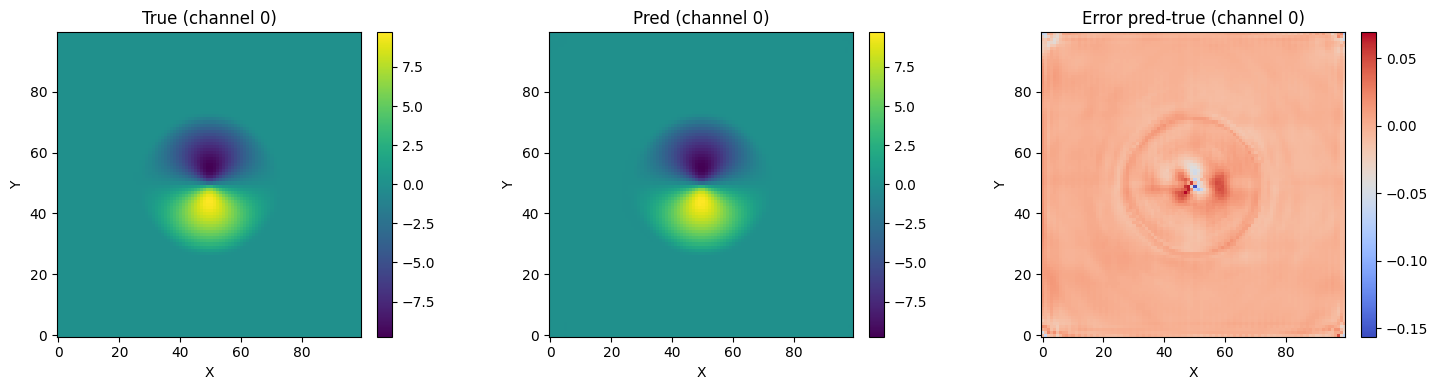

In [6]:
# Quick visualization for one channel
c = int(CHANNEL_TO_SHOW)
if c < 0 or c >= y_pred.shape[1]:
    raise IndexError(f'CHANNEL_TO_SHOW must be in [0, {y_pred.shape[1]-1}]')

pred_map = y_pred[0, c].detach().cpu().numpy()
true_map = y_ref[0, c].detach().cpu().numpy()
err_map = pred_map - true_map

vmin = min(pred_map.min(), true_map.min())
vmax = max(pred_map.max(), true_map.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(true_map, origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
axes[0].set_title(f'True (channel {c})')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(pred_map, origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
axes[1].set_title(f'Pred (channel {c})')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(err_map, origin='lower', cmap='coolwarm')
axes[2].set_title(f'Error pred-true (channel {c})')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.tight_layout()
plt.show()


arr shape: (273, 5, 100, 100, 12)
Z path: /N/slate/kmluong/regDL-TCIP/CMIP6/level_2_data/wrf_tropical_cyclone_track_5f_12v_dataset_Z.npy
Z shape: (2731, 4)
cm6lat shape: (719, 899)
cm6lon shape: (719, 899)
step_in: 3

frame_ids: [0, 1, 2, 3]
lo: [135.22 134.05 132.88 131.71]
la: [16.23 17.25 18.27 19.29]

Map point 0
target lon/lat: 135.22 16.23
used lon: 135.22
nearest iy/ix: 136 377
nearest lon/lat: 135.2178 16.230347
crop y0/y1/x0/x1: (86, 186, 327, 427)
center position inside crop: 50 50

Map point 1
target lon/lat: 134.05 17.25
used lon: 134.05
nearest iy/ix: 147 365
nearest lon/lat: 134.01494 17.286125
crop y0/y1/x0/x1: (97, 197, 315, 415)
center position inside crop: 50 50

Map point 2
target lon/lat: 132.88 18.27
used lon: 132.88
nearest iy/ix: 157 354
nearest lon/lat: 132.91232 18.240707
crop y0/y1/x0/x1: (107, 207, 304, 404)
center position inside crop: 50 50

Map point 3
target lon/lat: 131.71 19.29
used lon: 131.71
nearest iy/ix: 168 342
nearest lon/lat: 131.70946 19.284721

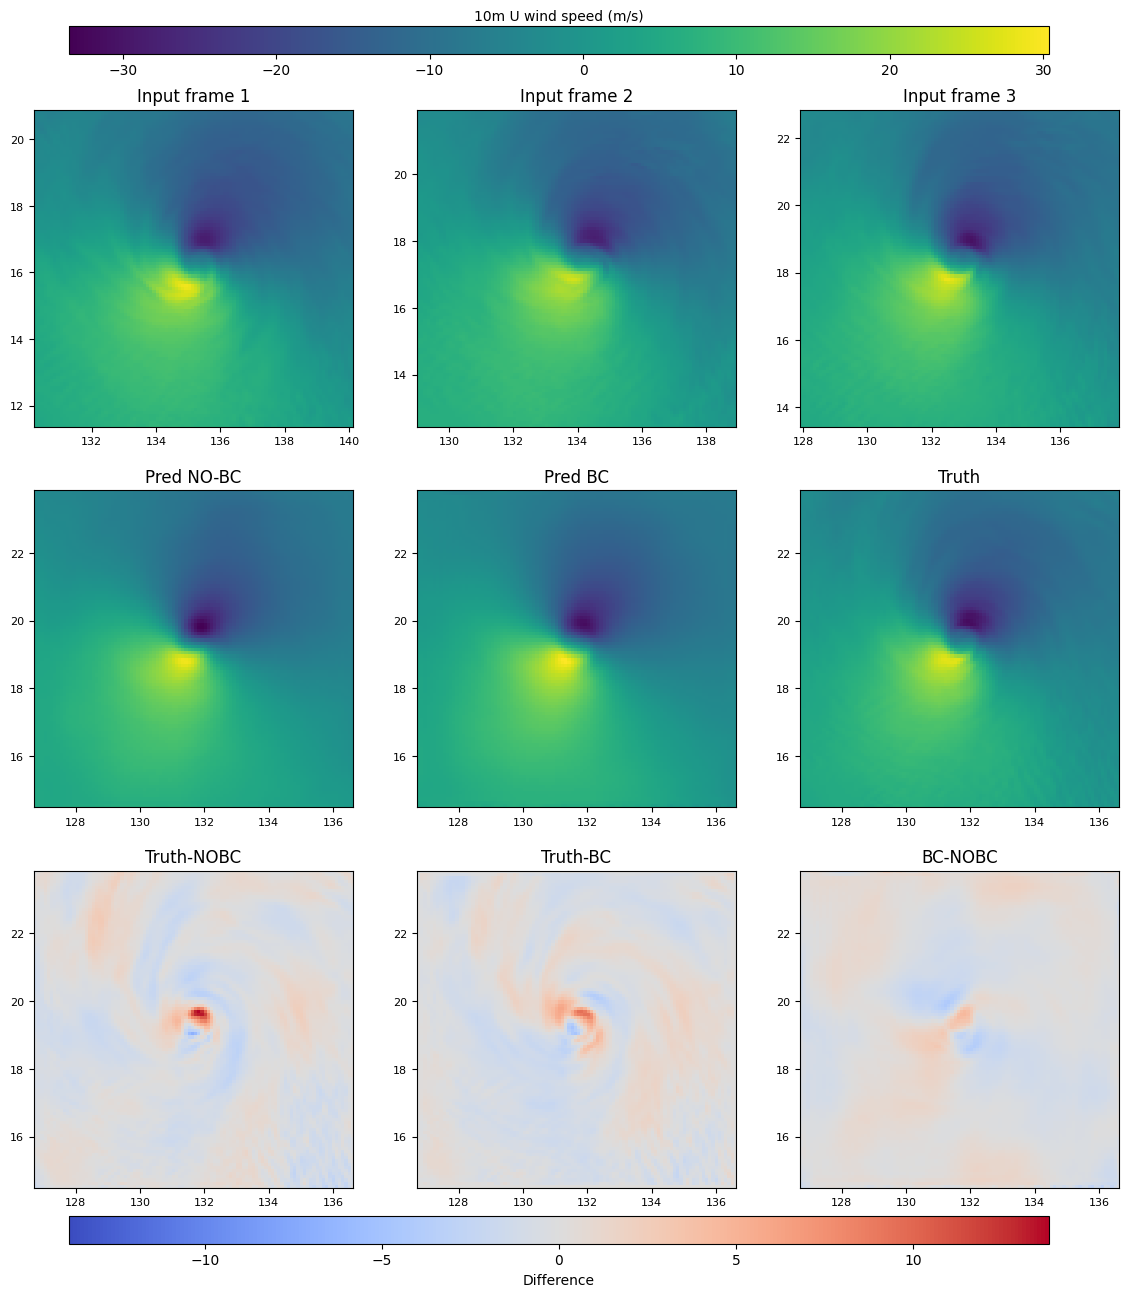

In [24]:
# ===== 12-panel figure + extract lat/lon map from Z =====
# Shape assumption:
#   arr: (sample, frame, h, w, c)
#   Z:   (sample, frame, 4) = [lat, lon, sinDOY, cosDOY]
#
# In maps  = first 3 frames
# Out map  = last / target frame
# Plot     = frame 0 and channel 0 equivalent from model window

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# =========================
# User inputs
# =========================
DS = "CMIP6"
DATA_SOURCE = f"/N/slate/kmluong/regDL-TCIP/{DS}/tmp"
LEVEL2_SOURCE = f"/N/slate/kmluong/regDL-TCIP/{DS}/level_2_data"

SPLIT = "test"
SAMPLE_N = 150
SAMPLE_F = 0
CHANNEL_TO_SHOW = 0
RIM = 1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CM6_LAT_PATH = f"/N/u/kmluong/BigRed200/Deep-learning-intensity-projection/test_space/cm6lat.npy"
CM6_LON_PATH = f"/N/u/kmluong/BigRed200/Deep-learning-intensity-projection/test_space/cm6lon.npy"

# Try these Z paths in order
Z_CANDIDATES = [
    f"{DATA_SOURCE}/{SPLIT}_Z.npy",
    f"{DATA_SOURCE}/Z.npy",
    f"{LEVEL2_SOURCE}/wrf_tropical_cyclone_track_5f_12v_dataset_Z.npy",
]

MODEL_CONFIG_PATH_BC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/AFNO-TCP-BC.json"
MODEL_CHECKPOINT_PATH_BC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/trained-AFNO-TCP-BC.pt"

MODEL_CONFIG_PATH_NBC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/AFNO-TCP-NO-BC.json"
MODEL_CHECKPOINT_PATH_NBC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/trained-AFNO-TCP-NO-BC.pt"


# =========================
# Helpers assumed available:
# load_model_from_paths, load_data_array, extract_bc_rim_from_y,
# make_rim_mask_like, make_smooth_phi, make_window_tensors
# =========================
def _run_inference_one_window(model, x, y_true, use_bc: bool, rim: int = 1):
    with torch.no_grad():
        x_in = x
        y_in = y_true

        if getattr(model, "x_scaler", None) is not None:
            x_in = model.x_scaler.norm(x_in)
        if getattr(model, "y_scaler", None) is not None:
            y_in = model.y_scaler.norm(y_in)

        if use_bc:
            b_fill = extract_bc_rim_from_y(y_in, rim=rim)
            bc_mask = make_rim_mask_like(y_in, rim=rim)
            bc_in = torch.cat([b_fill, bc_mask], dim=1)

            y_free = model(x_in, bc_in)

            phi = make_smooth_phi(
                H=y_in.shape[-2],
                W=y_in.shape[-1],
                rim=rim,
                device=y_in.device,
                dtype=y_in.dtype,
            )
            y_pred_norm = phi * y_free + (1.0 - phi) * b_fill
        else:
            y_pred_norm = model(x_in)

        if getattr(model, "y_scaler", None) is not None:
            y_pred = model.y_scaler.denorm(y_pred_norm)
            y_ref = y_true
        else:
            y_pred = y_pred_norm
            y_ref = y_true

    return y_pred, y_ref


def find_existing_path(paths):
    """Return first existing path from candidate list."""
    for p in paths:
        if Path(p).exists():
            return p
    raise FileNotFoundError("No Z file found. Tried:\n" + "\n".join(paths))


def find_center_index(lat2d, lon2d, target_lat, target_lon):
    """Find nearest grid point to target lat/lon, handling lon convention."""
    lon_use = float(target_lon)

    if np.nanmax(lon2d) > 180 and lon_use < 0:
        lon_use = lon_use % 360

    if np.nanmax(lon2d) <= 180 and lon_use > 180:
        lon_use = ((lon_use + 180) % 360) - 180

    dist2 = (lat2d - float(target_lat)) ** 2 + (lon2d - lon_use) ** 2
    iy, ix = np.unravel_index(np.nanargmin(dist2), dist2.shape)
    return iy, ix, lon_use


def crop_around_center(lat2d, lon2d, center_y, center_x, size=100):
    """Extract size x size lat/lon crop centered as close as possible."""
    half = size // 2
    H, W = lat2d.shape

    y0 = max(0, min(center_y - half, H - size))
    x0 = max(0, min(center_x - half, W - size))
    y1 = y0 + size
    x1 = x0 + size

    return lat2d[y0:y1, x0:x1], lon2d[y0:y1, x0:x1], (y0, y1, x0, x1)


def extract_latlon_crops_for_track(lat2d, lon2d, lo_arr, la_arr, size=100):
    """Extract one 100x100 lat/lon map for each lon/lat track point."""
    lo_arr = np.asarray(lo_arr).reshape(-1)
    la_arr = np.asarray(la_arr).reshape(-1)

    lat_crops, lon_crops = [], []
    crop_indices, center_indices = [], []

    for k, (lo_k, la_k) in enumerate(zip(lo_arr, la_arr)):
        iy, ix, lo_use = find_center_index(lat2d, lon2d, la_k, lo_k)
        lat_crop, lon_crop, crop_idx = crop_around_center(lat2d, lon2d, iy, ix, size=size)

        lat_crops.append(lat_crop)
        lon_crops.append(lon_crop)
        crop_indices.append(crop_idx)
        center_indices.append((iy, ix))

        print(f"\nMap point {k}")
        print("target lon/lat:", lo_k, la_k)
        print("used lon:", lo_use)
        print("nearest iy/ix:", iy, ix)
        print("nearest lon/lat:", lon2d[iy, ix], lat2d[iy, ix])
        print("crop y0/y1/x0/x1:", crop_idx)
        print("center position inside crop:", iy - crop_idx[0], ix - crop_idx[2])

    return np.stack(lat_crops), np.stack(lon_crops), crop_indices, center_indices


def get_extent_from_latlon(lat_crop, lon_crop):
    """Return imshow extent = [lon_min, lon_max, lat_min, lat_max]."""
    return [
        float(np.nanmin(lon_crop)),
        float(np.nanmax(lon_crop)),
        float(np.nanmin(lat_crop)),
        float(np.nanmax(lat_crop)),
    ]


# =========================
# Load data
# =========================
arr, _ = load_data_array(DATA_SOURCE, split=SPLIT)
print("arr shape:", arr.shape)

z_path = find_existing_path(Z_CANDIDATES)
Z = np.load(z_path, mmap_mode="r")
print("Z path:", z_path)
print("Z shape:", Z.shape)

cm6lat = np.load(CM6_LAT_PATH)[0]
cm6lon = np.load(CM6_LON_PATH)[0]
print("cm6lat shape:", cm6lat.shape)
print("cm6lon shape:", cm6lon.shape)


# =========================
# Load models
# =========================
model_bc, meta_bc = load_model_from_paths(
    config_path=MODEL_CONFIG_PATH_BC,
    checkpoint_path=MODEL_CHECKPOINT_PATH_BC,
    map_location=DEVICE,
    strict=True,
    eval_mode=True,
)
model_bc = model_bc.to(DEVICE)
step_in_bc = int(meta_bc["config"]["num_times"])

model_nbc, meta_nbc = load_model_from_paths(
    config_path=MODEL_CONFIG_PATH_NBC,
    checkpoint_path=MODEL_CHECKPOINT_PATH_NBC,
    map_location=DEVICE,
    strict=True,
    eval_mode=True,
)
model_nbc = model_nbc.to(DEVICE)
step_in_nbc = int(meta_nbc["config"]["num_times"])

step_in = min(step_in_bc, step_in_nbc)
print("step_in:", step_in)


# =========================
# Build model window
# =========================
x, y_true = make_window_tensors(arr, SAMPLE_N, SAMPLE_F, step_in=step_in, device=DEVICE)

T = x.shape[1]
if T < 3:
    raise ValueError("Need >=3 input frames")

c = int(CHANNEL_TO_SHOW)

in_maps = [x[0, t, c].detach().cpu().numpy() for t in range(3)]
truth_map = y_true[0, c].detach().cpu().numpy()


# =========================
# Extract lo/la from Z
# =========================
# Z convention: [lat, lon, sinDOY, cosDOY]
LAT_Z_IDX = 0
LON_Z_IDX = 1

frame_ids = [
    SAMPLE_F,
    SAMPLE_F + 1,
    SAMPLE_F + 2,
    SAMPLE_F + step_in,
]

lo = np.array([135.22, 134.05, 132.88, 131.71])
la = np.array([16.23, 17.25, 18.27, 19.29])

print("\nframe_ids:", frame_ids)
print("lo:", lo)
print("la:", la)


# =========================
# Extract 100x100 lat/lon maps
# =========================
lat_crops, lon_crops, crop_indices, center_indices = extract_latlon_crops_for_track(
    lat2d=cm6lat,
    lon2d=cm6lon,
    lo_arr=lo,
    la_arr=la,
    size=100,
)

in_extents = [
    get_extent_from_latlon(lat_crops[0], lon_crops[0]),
    get_extent_from_latlon(lat_crops[1], lon_crops[1]),
    get_extent_from_latlon(lat_crops[2], lon_crops[2]),
]
out_extent = get_extent_from_latlon(lat_crops[3], lon_crops[3])

print("\nInput extents:", in_extents)
print("Output extent:", out_extent)


# =========================
# Predict
# =========================
y_pred_bc, _ = _run_inference_one_window(model_bc, x, y_true, use_bc=True, rim=RIM)
y_pred_nbc, _ = _run_inference_one_window(model_nbc, x, y_true, use_bc=False, rim=RIM)

pred_bc_map = y_pred_bc[0, c].detach().cpu().numpy()
pred_nbc_map = y_pred_nbc[0, c].detach().cpu().numpy()


# =========================
# Diagnostics
# =========================
d_truth_bc = truth_map - pred_bc_map
d_truth_nbc = truth_map - pred_nbc_map
d_bc_nbc = pred_bc_map - pred_nbc_map


# =========================
# Color scales
# =========================
field_maps = in_maps + [pred_bc_map, pred_nbc_map, truth_map]
vmin = min(float(np.nanmin(m)) for m in field_maps)
vmax = max(float(np.nanmax(m)) for m in field_maps)

diff_maps = [d_truth_bc, d_truth_nbc, d_bc_nbc]
dmax = max(float(np.nanmax(np.abs(m))) for m in diff_maps)
d_vmin, d_vmax = -dmax, dmax


# =========================
# Plot
# =========================
fig, axes = plt.subplots(3, 3, figsize=(14, 14), sharex=False, sharey=False)

# Row 1: Inputs
for j in range(3):
    im_field = axes[0, j].imshow(
        in_maps[j],
        origin="lower",
        extent=in_extents[j],
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",
        aspect="auto",
    )

# Row 2: Predictions + Truth
axes[1, 0].imshow(pred_nbc_map, origin="lower", extent=out_extent,
                  vmin=vmin, vmax=vmax, cmap="viridis", aspect="auto")

axes[1, 1].imshow(pred_bc_map, origin="lower", extent=out_extent,
                  vmin=vmin, vmax=vmax, cmap="viridis", aspect="auto")

axes[1, 2].imshow(truth_map, origin="lower", extent=out_extent,
                  vmin=vmin, vmax=vmax, cmap="viridis", aspect="auto")

# Row 3: Diagnostics
im_diff = axes[2, 0].imshow(d_truth_nbc, origin="lower", extent=out_extent,
                           vmin=d_vmin, vmax=d_vmax, cmap="coolwarm", aspect="auto")

axes[2, 1].imshow(d_truth_bc, origin="lower", extent=out_extent,
                  vmin=d_vmin, vmax=d_vmax, cmap="coolwarm", aspect="auto")

axes[2, 2].imshow(d_bc_nbc, origin="lower", extent=out_extent,
                  vmin=d_vmin, vmax=d_vmax, cmap="coolwarm", aspect="auto")

# =========================
# Titles
# =========================
titles = [
    ["Input frame 1", "Input frame 2", "Input frame 3"],
    ["Pred NO-BC", "Pred BC", "Truth"],
    ["Truth-NOBC", "Truth-BC", "BC-NOBC"],
]

for i in range(3):
    for j in range(3):
        axes[i, j].set_title(titles[i][j])
        axes[i, j].tick_params(labelsize=8)

# =========================
# TOP COLORBAR 
# =========================
cbar_ax_top = fig.add_axes([0.15, 0.92, 0.7, 0.02])  
# [left, bottom, width, height] (figure coords)

cbar_top = fig.colorbar(
    im_field,
    cax=cbar_ax_top,
    orientation="horizontal"
)
cbar_top.set_label("10m U wind speed (m/s)")
cbar_top.ax.xaxis.set_label_position('top')


# =========================
# BOTTOM COLORBAR
# =========================
cbar_ax_bottom = fig.add_axes([0.15, 0.07, 0.7, 0.02])

cbar_bottom = fig.colorbar(
    im_diff,
    cax=cbar_ax_bottom,
    orientation="horizontal"
)
cbar_bottom.set_label("Difference")


plt.savefig("visualization_map.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    """Find repository root by checking required folders."""
    start = start.resolve()
    candidates = [start, *start.parents]

    for p in candidates:
        if (p / "module").exists() and (p / "configs").exists():
            return p

    fallback = Path("/N/u/kmluong/BigRed200/regDL-TCIP")
    if fallback.exists():
        return fallback

    raise FileNotFoundError(
        "Cannot find repo root (folder containing module/ and configs/)."
    )


REPO_ROOT = find_repo_root(Path.cwd())

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from visualization.model_loader import load_model_from_paths
from module.training.datasets import load_split_arrays
from module.training.masks import extract_bc_rim_from_y, make_rim_mask_like, make_smooth_phi

print("REPO_ROOT =", REPO_ROOT)


# ===== User inputs (minimum) =====
MODEL_CONFIG_PATH = "/N/slate/kmluong/regDL-TCIP/IDEALIZED/checkpoints/AFNO-TCP-NO-BC.json"
MODEL_CHECKPOINT_PATH = "/N/slate/kmluong/regDL-TCIP/IDEALIZED/checkpoints/trained-AFNO-TCP-NO-BC.pt"
DATA_SOURCE = "/N/slate/kmluong/regDL-TCIP/IDEALIZED/tmp"

SAMPLE_N = 0
SAMPLE_F = 0


# ===== Optional =====
SPLIT = "test"         # used if DATA_SOURCE is temp dir: train/val/test
RIM = 1                # used for BC architecture
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHANNEL_TO_SHOW = 0

print("DEVICE =", DEVICE)


def load_data_array(data_source: str | Path, split: str = "test"):
    """Load data from a temp directory or a .npy file."""
    p = Path(data_source)

    if p.is_dir():
        train, val, test = load_split_arrays(p)
        split = split.lower()

        if split == "train":
            arr = train
        elif split == "val":
            if val is None:
                raise ValueError("No val.npy found in this temp dir.")
            arr = val
        elif split == "test":
            arr = test
        else:
            raise ValueError(f"Invalid split: {split}")

        source_kind = f"temp_dir:{split}"

    else:
        if p.suffix != ".npy":
            raise ValueError(f"DATA_SOURCE must be temp dir or .npy file, got: {p}")

        arr = np.load(p, mmap_mode="r")
        source_kind = "npy"

    if arr.ndim != 5:
        raise ValueError(f"Data must have shape [N,F,H,W,C], got: {arr.shape}")

    return arr, source_kind


def make_window_tensors(arr, n_idx: int, f_idx: int, step_in: int, device: str):
    """Create one input window and one target frame."""
    N, F, H, W, C = arr.shape

    if not (0 <= n_idx < N):
        raise IndexError(f"SAMPLE_N out of range [0, {N - 1}]")

    if not (0 <= f_idx <= F - step_in - 1):
        raise IndexError(
            f"SAMPLE_F out of range [0, {F - step_in - 1}] "
            f"to keep a valid target frame (F={F}, step_in={step_in})"
        )

    x_np = arr[n_idx, f_idx:f_idx + step_in, ...]
    y_np = arr[n_idx, f_idx + step_in, ...]

    # [T,H,W,C] -> [1,T,C,H,W]
    x = torch.from_numpy(np.transpose(x_np, (0, 3, 1, 2)).copy())
    x = x.float().unsqueeze(0).to(device)

    # [H,W,C] -> [1,C,H,W]
    y = torch.from_numpy(np.transpose(y_np, (2, 0, 1)).copy())
    y = y.float().unsqueeze(0).to(device)

    return x, y


def run_inference_one_window(model, cfg, x, y_true, rim: int = 1):
    """Run one-window inference for either BC or NO-BC architecture."""
    arch = str(cfg.get("architecture", "")).lower()
    is_bc = arch in {"afno_v1"}

    with torch.no_grad():
        x_in = x
        y_in = y_true

        # Match training pipeline: normalize input when scaler exists.
        if getattr(model, "x_scaler", None) is not None:
            x_in = model.x_scaler.norm(x_in)

        # Normalize target only for BC extraction if y_scaler exists.
        if getattr(model, "y_scaler", None) is not None:
            y_in = model.y_scaler.norm(y_in)

        if is_bc:
            # Build boundary condition input from target rim.
            b_fill = extract_bc_rim_from_y(y_in, rim=rim)
            bc_mask = make_rim_mask_like(y_in, rim=rim)
            bc_in = torch.cat([b_fill, bc_mask], dim=1)

            y_free = model(x_in, bc_in)

            # Smoothly blend model output with known rim boundary.
            phi = make_smooth_phi(
                H=y_in.shape[-2],
                W=y_in.shape[-1],
                rim=rim,
                device=y_in.device,
                dtype=y_in.dtype,
            )

            y_pred_norm = phi * y_free + (1.0 - phi) * b_fill

        else:
            y_pred_norm = model(x_in)

        # Denormalize prediction if scaler exists.
        if getattr(model, "y_scaler", None) is not None:
            y_pred = model.y_scaler.denorm(y_pred_norm)
            y_true_out = y_true
        else:
            y_pred = y_pred_norm
            y_true_out = y_true

    return y_pred, y_true_out


# ============================================================
# 1) Load model from 2 paths: JSON config + PyTorch checkpoint
# ============================================================
model, meta = load_model_from_paths(
    config_path=MODEL_CONFIG_PATH,
    checkpoint_path=MODEL_CHECKPOINT_PATH,
    map_location=DEVICE,
    strict=True,
    eval_mode=True,
)

model = model.to(DEVICE)
cfg = meta["config"]


# ============================================================
# 2) Load data [N,F,H,W,C]
# ============================================================
arr, source_kind = load_data_array(DATA_SOURCE, split=SPLIT)


# ============================================================
# 3) Build one window from SAMPLE_N and SAMPLE_F
# ============================================================
step_in = int(cfg["num_times"])

x, y_true = make_window_tensors(
    arr,
    SAMPLE_N,
    SAMPLE_F,
    step_in=step_in,
    device=DEVICE,
)

print("source_kind =", source_kind)
print("data shape =", arr.shape, "[N,F,H,W,C]")
print("x shape =", tuple(x.shape), "[B,T,C,H,W]")
print("y_true shape =", tuple(y_true.shape), "[B,C,H,W]")
print("architecture =", cfg["architecture"])


# ============================================================
# 4) Inference
# ============================================================
y_pred, y_ref = run_inference_one_window(
    model,
    cfg,
    x,
    y_true,
    rim=RIM,
)

mae = (y_pred - y_ref).abs().mean().item()
mse = torch.mean((y_pred - y_ref) ** 2).item()

print(f"Sample (N={SAMPLE_N}, F={SAMPLE_F}) done")
print("y_pred shape =", tuple(y_pred.shape))
print(f"MAE = {mae:.6f}, MSE = {mse:.6f}")


# ============================================================
# 5) Final plot only: True / Pred / Error
# ============================================================
c = int(CHANNEL_TO_SHOW)

if c < 0 or c >= y_pred.shape[1]:
    raise IndexError(f"CHANNEL_TO_SHOW must be in [0, {y_pred.shape[1] - 1}]")

pred_map = y_pred[0, c].detach().cpu().numpy()
true_map = y_ref[0, c].detach().cpu().numpy()
err_map = pred_map - true_map

vmin = min(pred_map.min(), true_map.min())
vmax = max(pred_map.max(), true_map.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(
    true_map,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
    cmap="viridis",
)
axes[0].set_title(f"True (channel {c})")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(
    pred_map,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
    cmap="viridis",
)
axes[1].set_title(f"Pred (channel {c})")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(
    err_map,
    origin="lower",
    cmap="coolwarm",
)
axes[2].set_title(f"Error pred - true (channel {c})")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.tight_layout()
plt.show()